2026-02-23 15:56:17.319258: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 15:56:17.354782: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 15:56:18.888762: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 15:56:22.523996: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur


Training model for Linear Equation


2026-02-23 15:56:25.973098: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Linear Equation Test MSE: 0.0004
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


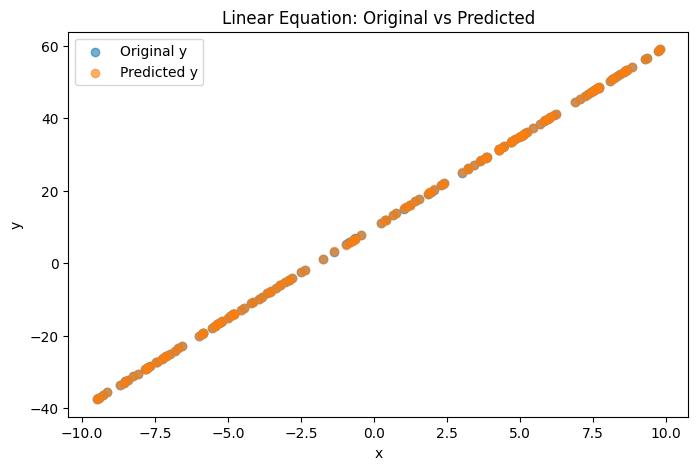

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted value: 44.998196

Training model for Quadratic Equation
Quadratic Equation Test MSE: 0.5123
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


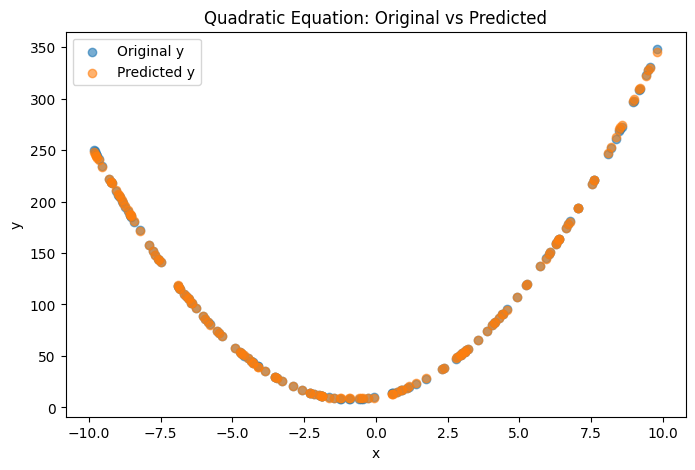

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted value: 191.7144

Training model for Cubic Equation
Cubic Equation Test MSE: 312.6324
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


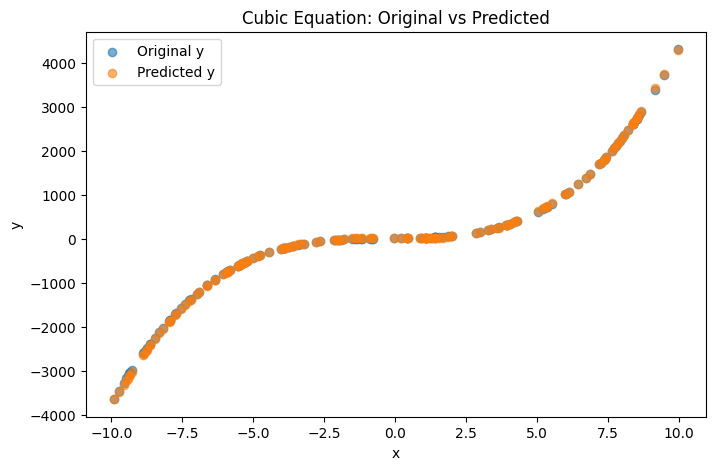

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted value: 1565.7759


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# Equations
def equation_linear(x):
    return 5*x + 10
def equation_quadratic(x):
    return 3*x**2 + 5*x + 10
def equation_cubic(x):
    return 4*x**3 + 3*x**2 + 5*x + 10
# Data Generation
def data_gen(func, n=1000):
    x = np.random.uniform(-10, 10, n).astype(np.float32)
    y = func(x).astype(np.float32)
    return x.reshape(-1,1), y
# Train,Validation,Test Split
def split(x, y, train_ratio=0.7, val_ratio=0.15):
    n = len(x)
    train_n = int(n * train_ratio)
    val_n = int(n * val_ratio)
    trainx, trainy = x[:train_n], y[:train_n]
    valx, valy = x[train_n:train_n+val_n], y[train_n:train_n+val_n]
    testx, testy = x[train_n+val_n:], y[train_n+val_n:]
    return trainx, trainy, valx, valy, testx, testy
# Model Generator (Adjustable Depth)
def model_gen(hidden_units=64, layers=2):
    inputs = Input((1,))
    x = inputs
    for i in range(layers):
        x = Dense(hidden_units, activation='relu')(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.01), loss='mse')
    return model
    # Predict a single value
    x_new = np.array([[7]], dtype=np.float32)
    prediction = model.predict(x_new)
    # shape must be (1,1)
    print("Predicted value:", prediction[0][0])
    # Plot Function
def show(testX, testY, y_pred, title):
    plt.figure(figsize=(8,5))
    plt.scatter(testX, testY, label='Original y', alpha=0.6)
    plt.scatter(testX, y_pred, label='Predicted y', alpha=0.6)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
# Training Procedure
def train_model(func, name, layers):
    print(f"\nTraining model for {name}")
    x, y = data_gen(func)
    trainx, trainy, valx, valy, testx, testy = split(x, y)
    model = model_gen(hidden_units=64, layers=layers)
    history = model.fit(trainx, trainy,
    validation_data=(valx, valy),
    epochs=60,
    batch_size=32,
    verbose=0)
    test_loss = model.evaluate(testx, testy, verbose=0)
    print(f"{name} Test MSE: {test_loss:.4f}")
    y_pred = model.predict(testx)
    show(testx, testy, y_pred, f"{name}: Original vs Predicted")
    # Predict a single value
    x_new = np.array([[7]], dtype=np.float32)
    prediction = model.predict(x_new)
    # shape must be (1,1)
    print("Predicted value:", prediction[0][0])
    return test_loss
if __name__ == "__main__":
    # Linear
    train_model(equation_linear, "Linear Equation", layers=1)
    # Quadratic
    train_model(equation_quadratic, "Quadratic Equation", layers=2)
    # Cubic
    train_model(equation_cubic, "Cubic Equation", layers=3)